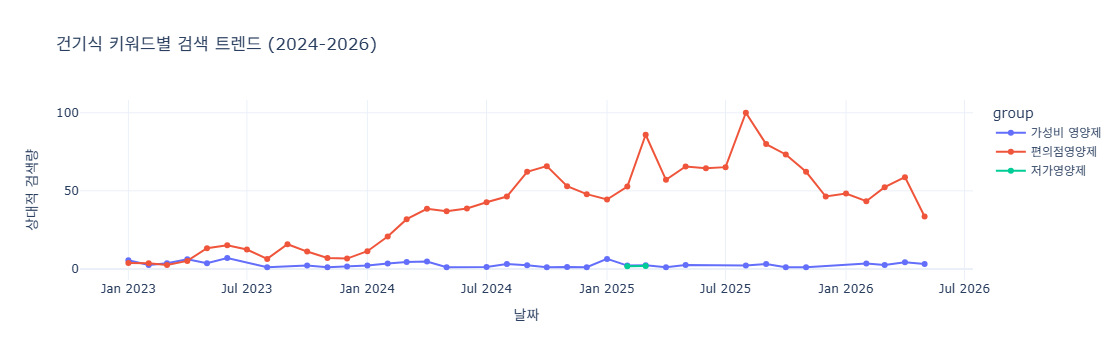

In [88]:
import os
import sys
import urllib.request
import json
import pandas as pd
import plotly.express as px

# 1. 인증 정보 설정 (이미지에서 확인하신 본인 정보를 넣으세요)
client_id = "iQYuA4jIAZWE78ZCH4p9" 
client_secret = "7MP3lY3dzz"
url = "https://openapi.naver.com/v1/datalab/search"

# 2. 분석 키워드 설정
target_keywords = ["가성비 영양제","편의점영양제","저가영양제"]

# 3. 키워드별 개별 그룹 자동 생성
keyword_groups = []
for kw in target_keywords:
    keyword_groups.append({
        "groupName": kw, 
        "keywords": [kw] 
    })

# 4. API 요청 본문 작성
body = {
    "startDate": "2023-01-01",
    "endDate": "2026-05-14",
    "timeUnit": "month",
    "keywordGroups": keyword_groups
}
body_json = json.dumps(body, ensure_ascii=False)

# 5. API 호출 실행
request = urllib.request.Request(url)
request.add_header("X-Naver-Client-Id", client_id)
request.add_header("X-Naver-Client-Secret", client_secret)
request.add_header("Content-Type", "application/json")

try:
    response = urllib.request.urlopen(request, data=body_json.encode("utf-8"))
    rescode = response.getcode()
    
    if rescode == 200:
        response_body = response.read()
        data = json.loads(response_body)
        
        # 6. 데이터프레임 변환
        df_list = []
        for res in data['results']:
            temp_df = pd.DataFrame(res['data'])
            temp_df['group'] = res['title']
            df_list.append(temp_df)
        
        search_keywords_compare = pd.concat(df_list)
        
        # 7. 시각화 (fig.write_image 부분을 삭제했습니다!)
        fig = px.line(search_keywords_compare, x='period', y='ratio', color='group',
                      title='건기식 키워드별 검색 트렌드 (2024-2026)',
                      labels={'period': '날짜', 'ratio': '상대적 검색량'},
                      markers=True,
                      template='plotly_white')
        
        fig.show() # 이제 에러 없이 그래프가 화면에 뜹니다!

    else:
        print(f"Error: API 요청 실패 (Code: {rescode})")

except Exception as e:
    print(f"Error 발생: {e}")

    

In [86]:
search_keywords_compare.to_csv("네이버트랜드분석1차.csv", index=False, encoding="utf-8-sig")
print("💾 네이버트랜드분석1차.csv 파일 저장 완료!")

💾 네이버트랜드분석1차.csv 파일 저장 완료!


📊 네이버 데이터랩 수집 완료 (search_contrast_kw_compare 생성 성공)
💾 반대_검색어_트랜드.csv 파일이 성공적으로 생성 및 저장되었습니다!


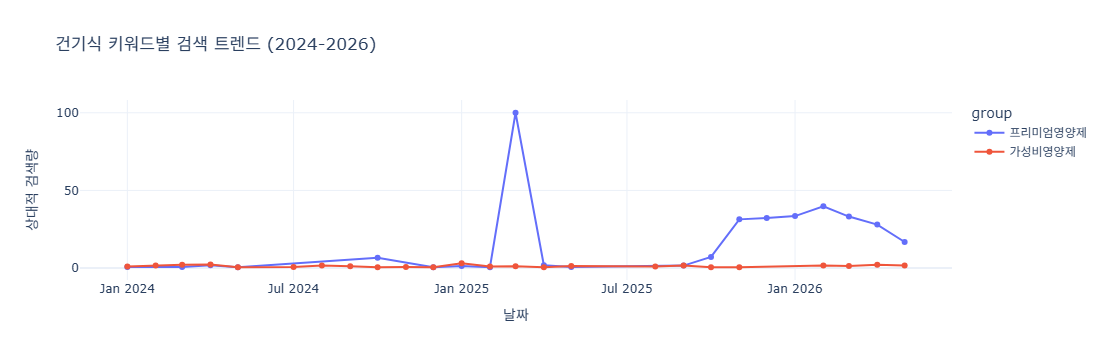

In [2]:
import os
import sys
import urllib.request
import json
import pandas as pd
import plotly.express as px

# 1. 인증 정보 설정 (이미지에서 확인하신 본인 정보를 넣으세요)
client_id = "iQYuA4jIAZWE78ZCH4p9" 
client_secret = "7MP3lY3dzz"
url = "https://openapi.naver.com/v1/datalab/search"

# 2. 분석 키워드 설정
target_keywords = ["프리미엄영양제", "가성비영양제"]

# 3. 키워드별 개별 그룹 자동 생성
keyword_groups = []
for kw in target_keywords:
    keyword_groups.append({
        "groupName": kw, 
        "keywords": [kw] 
    })

# 4. API 요청 본문 작성
body = {
    "startDate": "2024-01-01",
    "endDate": "2026-05-14",
    "timeUnit": "month",
    "keywordGroups": keyword_groups
}
body_json = json.dumps(body, ensure_ascii=False)

# 5. API 호출 실행
request = urllib.request.Request(url)
request.add_header("X-Naver-Client-Id", client_id)
request.add_header("X-Naver-Client-Secret", client_secret)
request.add_header("Content-Type", "application/json")

try:
    response = urllib.request.urlopen(request, data=body_json.encode("utf-8"))
    rescode = response.getcode()
    
    if rescode == 200:
        response_body = response.read()
        data = json.loads(response_body)
        
        # 6. 데이터프레임 변환
        df_list = []
        for res in data['results']:
            temp_df = pd.DataFrame(res['data'])
            temp_df['group'] = res['title']
            df_list.append(temp_df)
        
        search_contrast_kw_compare = pd.concat(df_list)
        print("📊 네이버 데이터랩 수집 완료 (search_contrast_kw_compare 생성 성공)")
        
        # -----------------------------------------------------------
        # 🎯 [CSV 저장 로직] 독립된 CSV 파일로 깔끔하게 저장하기
        # -----------------------------------------------------------
        file_name = "반대_검색어_트랜드.csv"
        
        # 엑셀에서 열었을 때 한글이 깨지지 않도록 encoding='utf-8-sig' 처리
        search_contrast_kw_compare.to_csv(file_name, index=False, encoding="utf-8-sig")
        print(f"💾 {file_name} 파일이 성공적으로 생성 및 저장되었습니다!")
        
        # 7. 시각화 (fig.write_image 부분을 삭제했습니다!)
        fig = px.line(search_contrast_kw_compare, x='period', y='ratio', color='group',
                      title='건기식 키워드별 검색 트렌드 (2024-2026)',
                      labels={'period': '날짜', 'ratio': '상대적 검색량'},
                      markers=True,
                      template='plotly_white')
        
        fig.show() # 이제 에러 없이 그래프가 화면에 뜹니다!

    else:
        print(f"Error: API 요청 실패 (Code: {rescode})")

except Exception as e:
    print(f"Error 발생: {e}")

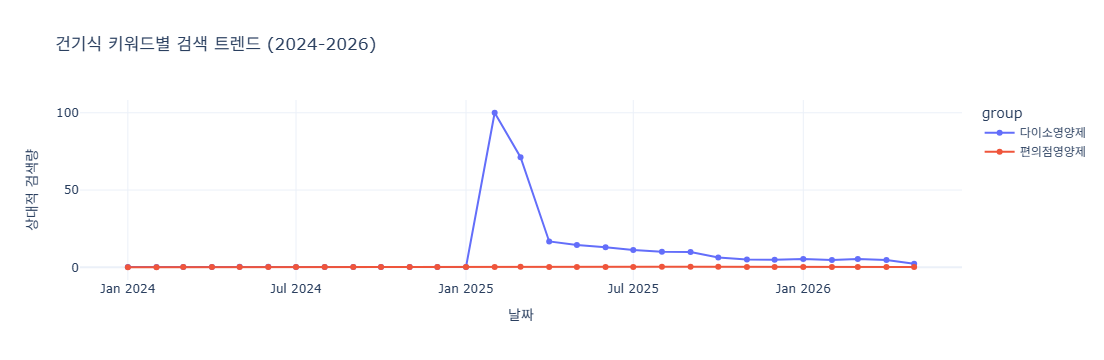

In [3]:
import os
import sys
import urllib.request
import json
import pandas as pd
import plotly.express as px

# 1. 인증 정보 설정 (이미지에서 확인하신 본인 정보를 넣으세요)
client_id = "iQYuA4jIAZWE78ZCH4p9" 
client_secret = "7MP3lY3dzz"
url = "https://openapi.naver.com/v1/datalab/search"

# 2. 분석 키워드 설정
target_keywords = ["다이소영양제", "편의점영양제"]

# 3. 키워드별 개별 그룹 자동 생성
keyword_groups = []
for kw in target_keywords:
    keyword_groups.append({
        "groupName": kw, 
        "keywords": [kw] 
    })

# 4. API 요청 본문 작성
body = {
    "startDate": "2024-01-01",
    "endDate": "2026-05-14",
    "timeUnit": "month",
    "keywordGroups": keyword_groups
}
body_json = json.dumps(body, ensure_ascii=False)

# 5. API 호출 실행
request = urllib.request.Request(url)
request.add_header("X-Naver-Client-Id", client_id)
request.add_header("X-Naver-Client-Secret", client_secret)
request.add_header("Content-Type", "application/json")

try:
    response = urllib.request.urlopen(request, data=body_json.encode("utf-8"))
    rescode = response.getcode()
    
    if rescode == 200:
        response_body = response.read()
        data = json.loads(response_body)
        
        # 6. 데이터프레임 변환
        df_list = []
        for res in data['results']:
            temp_df = pd.DataFrame(res['data'])
            temp_df['group'] = res['title']
            df_list.append(temp_df)
        
        final_df = pd.concat(df_list)
        
        # 7. 시각화 (fig.write_image 부분을 삭제했습니다!)
        fig = px.line(final_df, x='period', y='ratio', color='group',
                      title='건기식 키워드별 검색 트렌드 (2024-2026)',
                      labels={'period': '날짜', 'ratio': '상대적 검색량'},
                      markers=True,
                      template='plotly_white')
        
        fig.show() # 이제 에러 없이 그래프가 화면에 뜹니다!

    else:
        print(f"Error: API 요청 실패 (Code: {rescode})")

except Exception as e:
    print(f"Error 발생: {e}")

💾 가성비영양제_연령별_검색트랜드.csv 파일이 성공적으로 저장되었습니다!


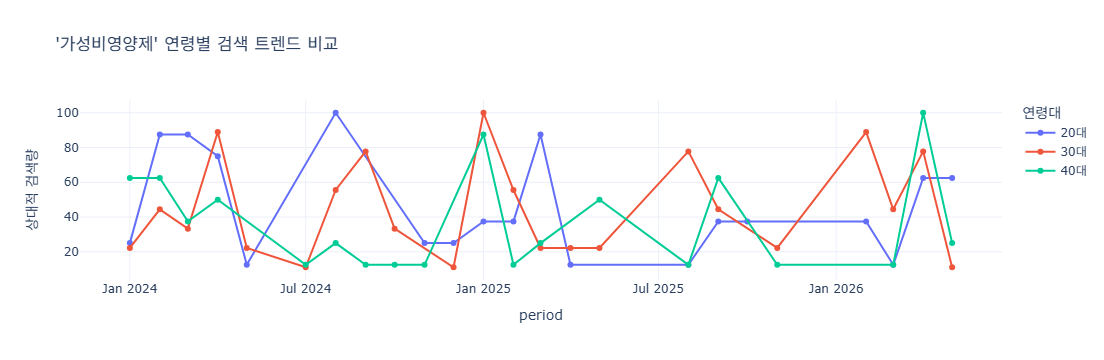

In [95]:
import urllib.request
import json
import pandas as pd
import plotly.express as px

client_id = "iQYuA4jIAZWE78ZCH4p9" 
client_secret = "7MP3lY3dzz"
url = "https://openapi.naver.com/v1/datalab/search"

# 1. 분석 설정
target_kw = "가성비영양제" # 가장 핵심인 키워드 하나를 기준으로 연령 비교
age_dict = {'20대': ['3', '4'], '30대': ['5', '6'], '40대': ['7', '8']}
all_data = []

# 2. 연령별 루프 실행 (연령별로 API를 따로 호출하여 수집)
for age_name, age_codes in age_dict.items():
    body = {
        "startDate": "2024-01-01",
        "endDate": "2026-05-14",
        "timeUnit": "month",
        "keywordGroups": [{"groupName": target_kw, "keywords": [target_kw]}],
        "ages": age_codes
    }
    
    request = urllib.request.Request(url)
    request.add_header("X-Naver-Client-Id", client_id)
    request.add_header("X-Naver-Client-Secret", client_secret)
    request.add_header("Content-Type", "application/json")
    
    response = urllib.request.urlopen(request, data=json.dumps(body).encode("utf-8"))
    res_data = json.loads(response.read())
    
    # 데이터 정리
    for item in res_data['results'][0]['data']:
        all_data.append({
            'period': item['period'],
            'ratio': item['ratio'],
            'age_group': age_name
        })

# 3. 데이터프레임 통합
df_age = pd.DataFrame(all_data)

# -----------------------------------------------------------
# 🎯 [CSV 저장 로직] 독립된 CSV 파일로 저장하기
# -----------------------------------------------------------
file_name = "가성비영양제_연령별_검색트랜드.csv"
df_age.to_csv(file_name, index=False, encoding="utf-8-sig")
print(f"💾 {file_name} 파일이 성공적으로 저장되었습니다!")
# -----------------------------------------------------------

# 4. 시각화 (연령별 비교)
fig = px.line(df_age, x='period', y='ratio', color='age_group',
              title=f"'{target_kw}' 연령별 검색 트렌드 비교",
              labels={'ratio': '상대적 검색량', 'age_group': '연령대'},
              markers=True, template='plotly_white')

fig.show()

💾 편의점영양제_연령별_검색트랜드.csv 파일이 성공적으로 저장되었습니다!


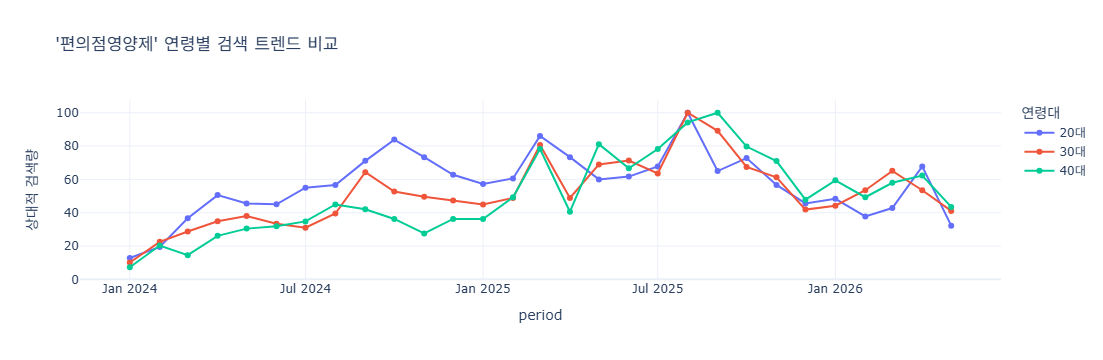

In [99]:
import urllib.request
import json
import pandas as pd
import plotly.express as px

client_id = "iQYuA4jIAZWE78ZCH4p9" 
client_secret = "7MP3lY3dzz"
url = "https://openapi.naver.com/v1/datalab/search"

# 1. 분석 설정
target_kw = "편의점영양제" # 가장 핵심인 키워드 하나를 기준으로 연령 비교
age_dict = {'20대': ['3', '4'], '30대': ['5', '6'], '40대': ['7', '8']}
all_data = []

# 2. 연령별 루프 실행 (연령별로 API를 따로 호출하여 수집)
for age_name, age_codes in age_dict.items():
    body = {
        "startDate": "2024-01-01",
        "endDate": "2026-05-14",
        "timeUnit": "month",
        "keywordGroups": [{"groupName": target_kw, "keywords": [target_kw]}],
        "ages": age_codes
    }
    
    request = urllib.request.Request(url)
    request.add_header("X-Naver-Client-Id", client_id)
    request.add_header("X-Naver-Client-Secret", client_secret)
    request.add_header("Content-Type", "application/json")
    
    response = urllib.request.urlopen(request, data=json.dumps(body).encode("utf-8"))
    res_data = json.loads(response.read())
    
    # 데이터 정리
    for item in res_data['results'][0]['data']:
        all_data.append({
            'period': item['period'],
            'ratio': item['ratio'],
            'age_group': age_name
        })

# 3. 데이터프레임 통합
df_age2 = pd.DataFrame(all_data)

# 🎯 [CSV 저장 로직] 독립된 CSV 파일로 저장하기
# -----------------------------------------------------------
file_name = "편의점영양제_연령별_검색트랜드.csv"
df_age2.to_csv(file_name, index=False, encoding="utf-8-sig")
print(f"💾 {file_name} 파일이 성공적으로 저장되었습니다!")
# -----------------------------------------------------------


# 4. 시각화 (연령별 비교)
fig = px.line(df_age2, x='period', y='ratio', color='age_group',
              title=f"'{target_kw}' 연령별 검색 트렌드 비교",
              labels={'ratio': '상대적 검색량', 'age_group': '연령대'},
              markers=True, template='plotly_white')

fig.show()

네이버 검색 결과 총 건수: 243,452건
최근 수집된 100개 중 2026년 이후 작성된 글: 85건


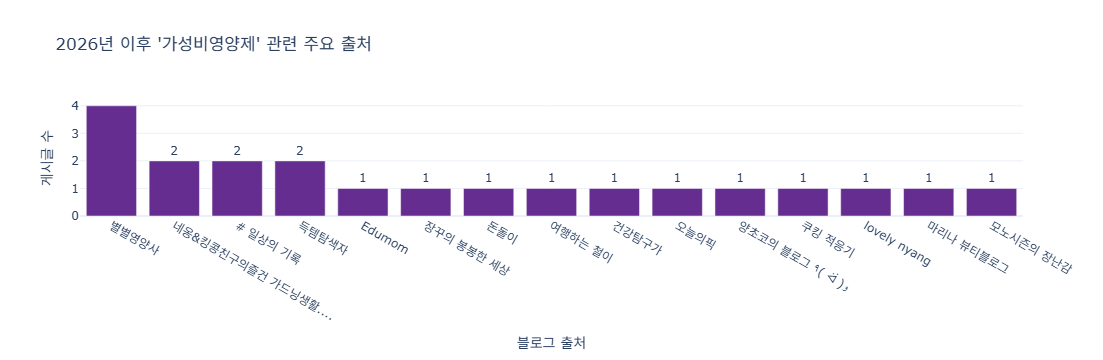

In [10]:
import os
import sys
import urllib.request
import json
import pandas as pd
import plotly.express as px

# 1. 네이버 개발자 센터에서 발급받은 키 입력
client_id = "iQYuA4jIAZWE78ZCH4p9" 
client_secret = "7MP3lY3dzz"
keyword = "가성비영양제"

# 2. 네이버 블로그 검색 API 호출
encText = urllib.parse.quote(keyword)
url = f"https://openapi.naver.com/v1/search/blog?query={encText}&display=100"

request = urllib.request.Request(url)
request.add_header("X-Naver-Client-Id", client_id)
request.add_header("X-Naver-Client-Secret", client_secret)

try:
    response = urllib.request.urlopen(request)
    if response.getcode() == 200:
        data = json.loads(response.read().decode('utf-8'))
        total_items = data['total']
        print(f"네이버 검색 결과 총 건수: {total_items:,}건")
        
        # 3. 데이터프레임 변환 및 날짜 보정
        df = pd.DataFrame(data['items'])
        df['postdate'] = df['postdate'].astype(str)
        df['postdate'] = pd.to_datetime(df['postdate'], format='%Y%m%d', errors='coerce')
        
        # 2026년 1월 1일 이후 데이터 필터링
        df_filtered = df[df['postdate'] >= '2026-01-01'].copy()
        print(f"최근 수집된 100개 중 2026년 이후 작성된 글: {len(df_filtered)}건")
        
        # 4. 시각화 데이터 가공 및 그래프 출력
        if not df_filtered.empty:
            df_count = df_filtered['bloggername'].value_counts().reset_index()
            df_count.columns = ['블로그 출처', '게시글 수']
            
            fig = px.bar(df_count.head(15), x='블로그 출처', y='게시글 수', 
                         title=f"2026년 이후 '{keyword}' 관련 주요 출처", 
                         text='게시글 수', template='plotly_white', 
                         color_discrete_sequence=['#652D90'])
            
            # [수정 완료] 'outer'에서 'outside'로 변경하여 에러를 해결했습니다.
            fig.update_traces(textposition='outside')
            
            fig.show()
        else:
            print("2026년 이후에 발행된 글이 수집 범위 내에 없습니다.")
    else:
        print("API 요청 실패 코드:", response.getcode())
except Exception as e:
    print(f"에러 발생: {e}")

💾 only가성비영양제_검색추이.csv 파일이 성공적으로 생성 및 저장되었습니다!


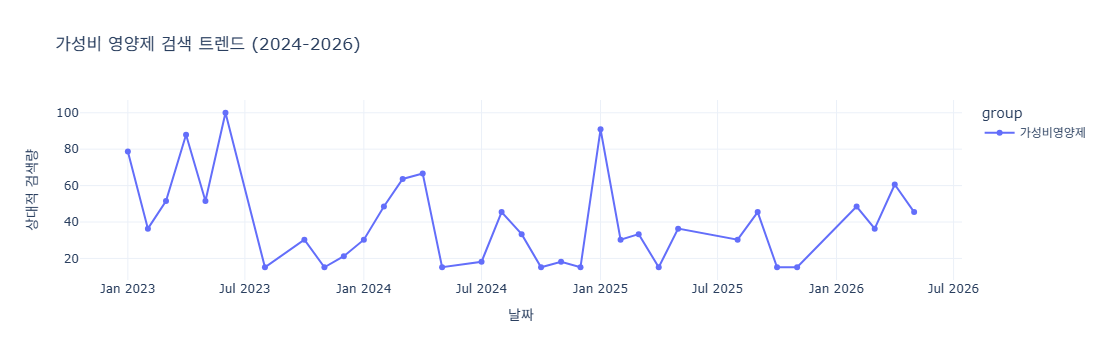

In [16]:
import os
import sys
import urllib.request
import json
import pandas as pd
import plotly.express as px

# 1. 인증 정보 설정 (이미지에서 확인하신 본인 정보를 넣으세요)
client_id = "iQYuA4jIAZWE78ZCH4p9" 
client_secret = "7MP3lY3dzz"
url = "https://openapi.naver.com/v1/datalab/search"

# 2. 분석 키워드 설정
target_keywords = ["가성비영양제"]

# 3. 키워드별 개별 그룹 자동 생성
keyword_groups = []
for kw in target_keywords:
    keyword_groups.append({
        "groupName": kw, 
        "keywords": [kw] 
    })

# 4. API 요청 본문 작성
body = {
    "startDate": "2023-01-01",
    "endDate": "2026-05-14",
    "timeUnit": "month",
    "keywordGroups": keyword_groups
}
body_json = json.dumps(body, ensure_ascii=False)

# 5. API 호출 실행
request = urllib.request.Request(url)
request.add_header("X-Naver-Client-Id", client_id)
request.add_header("X-Naver-Client-Secret", client_secret)
request.add_header("Content-Type", "application/json")

try:
    response = urllib.request.urlopen(request, data=body_json.encode("utf-8"))
    rescode = response.getcode()
    
    if rescode == 200:
        response_body = response.read()
        data = json.loads(response_body)
        
        # 6. 데이터프레임 변환
        df_list = []
        for res in data['results']:
            temp_df = pd.DataFrame(res['data'])
            temp_df['group'] = res['title']
            df_list.append(temp_df)
        
        cheap_search_trend = pd.concat(df_list)

        # -----------------------------------------------------------
        # 🎯 [CSV 저장 로직] 독립된 CSV 파일로 저장하기
        # -----------------------------------------------------------
        file_name = "only가성비영양제_검색추이.csv"
        cheap_search_trend.to_csv(file_name, index=False, encoding="utf-8-sig")
        print(f"💾 {file_name} 파일이 성공적으로 생성 및 저장되었습니다!")
        # -----------------------------------------------------------

        
        # 7. 시각화 (fig.write_image 부분을 삭제했습니다!)
        fig = px.line(cheap_search_trend, x='period', y='ratio', color='group',
                      title='가성비 영양제 검색 트렌드 (2024-2026)',
                      labels={'period': '날짜', 'ratio': '상대적 검색량'},
                      markers=True,
                      template='plotly_white')
        
        fig.show() # 이제 에러 없이 그래프가 화면에 뜹니다!

    else:
        print(f"Error: API 요청 실패 (Code: {rescode})")

except Exception as e:
    print(f"Error 발생: {e}")

    

In [37]:
print(final_df1.columns)

Index(['period', 'ratio', 'group'], dtype='object')


In [56]:
print(final_df3.columns)

Index(['period', 'ratio', 'group'], dtype='object')


In [65]:
print(final_df3[['period', 'ratio']])

        period      ratio
0   2024-01-01   33.33333
1   2024-02-01   53.33333
2   2024-03-01   70.00000
3   2024-04-01   73.33333
4   2024-05-01   16.66666
5   2024-07-01   20.00000
6   2024-08-01   50.00000
7   2024-09-01   36.66666
8   2024-10-01   16.66666
9   2024-11-01   20.00000
10  2024-12-01   16.66666
11  2025-01-01  100.00000
12  2025-02-01   33.33333
13  2025-03-01   36.66666
14  2025-04-01   16.66666
15  2025-05-01   40.00000
16  2025-08-01   33.33333
17  2025-09-01   50.00000
18  2025-10-01   16.66666
19  2025-11-01   16.66666
20  2026-02-01   53.33333
21  2026-03-01   40.00000
22  2026-04-01   66.66666
23  2026-05-01   50.00000


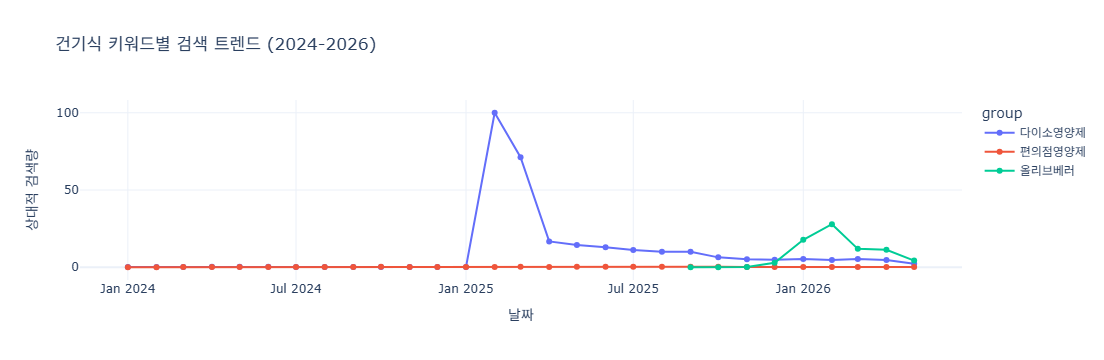

In [7]:
import os
import sys
import urllib.request
import json
import pandas as pd
import plotly.express as px

# 1. 인증 정보 설정 (이미지에서 확인하신 본인 정보를 넣으세요)
client_id = "iQYuA4jIAZWE78ZCH4p9" 
client_secret = "7MP3lY3dzz"
url = "https://openapi.naver.com/v1/datalab/search"

# 2. 분석 키워드 설정
target_keywords = ["다이소영양제", "편의점영양제","올리브베러"]

# 3. 키워드별 개별 그룹 자동 생성
keyword_groups = []
for kw in target_keywords:
    keyword_groups.append({
        "groupName": kw, 
        "keywords": [kw] 
    })

# 4. API 요청 본문 작성
body = {
    "startDate": "2024-01-01",
    "endDate": "2026-05-14",
    "timeUnit": "month",
    "keywordGroups": keyword_groups
}
body_json = json.dumps(body, ensure_ascii=False)

# 5. API 호출 실행
request = urllib.request.Request(url)
request.add_header("X-Naver-Client-Id", client_id)
request.add_header("X-Naver-Client-Secret", client_secret)
request.add_header("Content-Type", "application/json")

try:
    response = urllib.request.urlopen(request, data=body_json.encode("utf-8"))
    rescode = response.getcode()
    
    if rescode == 200:
        response_body = response.read()
        data = json.loads(response_body)
        
        # 6. 데이터프레임 변환
        df_list = []
        for res in data['results']:
            temp_df = pd.DataFrame(res['data'])
            temp_df['group'] = res['title']
            df_list.append(temp_df)
        
        final_df = pd.concat(df_list)
        
        # 7. 시각화 (fig.write_image 부분을 삭제했습니다!)
        fig = px.line(final_df, x='period', y='ratio', color='group',
                      title='건기식 키워드별 검색 트렌드 (2024-2026)',
                      labels={'period': '날짜', 'ratio': '상대적 검색량'},
                      markers=True,
                      template='plotly_white')
        
        fig.show() # 이제 에러 없이 그래프가 화면에 뜹니다!

    else:
        print(f"Error: API 요청 실패 (Code: {rescode})")

except Exception as e:
    print(f"Error 발생: {e}")

💾 only가성비영양제_검색추이.csv 파일이 성공적으로 생성 및 저장되었습니다!


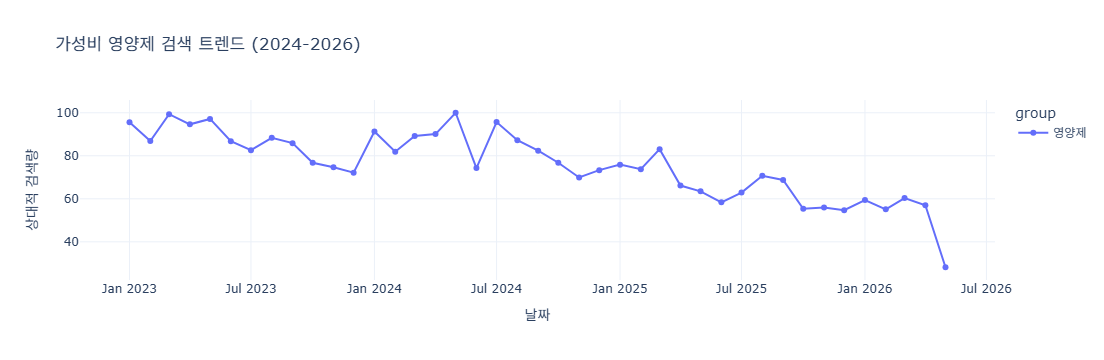

In [13]:
import os
import sys
import urllib.request
import json
import pandas as pd
import plotly.express as px

# 1. 인증 정보 설정 (이미지에서 확인하신 본인 정보를 넣으세요)
client_id = "iQYuA4jIAZWE78ZCH4p9" 
client_secret = "7MP3lY3dzz"
url = "https://openapi.naver.com/v1/datalab/search"

# 2. 분석 키워드 설정
target_keywords = ["영양제"]

# 3. 키워드별 개별 그룹 자동 생성
keyword_groups = []
for kw in target_keywords:
    keyword_groups.append({
        "groupName": kw, 
        "keywords": [kw] 
    })

# 4. API 요청 본문 작성
body = {
    "startDate": "2023-01-01",
    "endDate": "2026-05-14",
    "timeUnit": "month",
    "keywordGroups": keyword_groups
}
body_json = json.dumps(body, ensure_ascii=False)

# 5. API 호출 실행
request = urllib.request.Request(url)
request.add_header("X-Naver-Client-Id", client_id)
request.add_header("X-Naver-Client-Secret", client_secret)
request.add_header("Content-Type", "application/json")

try:
    response = urllib.request.urlopen(request, data=body_json.encode("utf-8"))
    rescode = response.getcode()
    
    if rescode == 200:
        response_body = response.read()
        data = json.loads(response_body)
        
        # 6. 데이터프레임 변환
        df_list = []
        for res in data['results']:
            temp_df = pd.DataFrame(res['data'])
            temp_df['group'] = res['title']
            df_list.append(temp_df)
        
        cheap_search_trend = pd.concat(df_list)

        # -----------------------------------------------------------
        # 🎯 [CSV 저장 로직] 독립된 CSV 파일로 저장하기
        # -----------------------------------------------------------
        file_name = "only가성비영양제_검색추이.csv"
        cheap_search_trend.to_csv(file_name, index=False, encoding="utf-8-sig")
        print(f"💾 {file_name} 파일이 성공적으로 생성 및 저장되었습니다!")
        # -----------------------------------------------------------

        
        # 7. 시각화 (fig.write_image 부분을 삭제했습니다!)
        fig = px.line(cheap_search_trend, x='period', y='ratio', color='group',
                      title='가성비 영양제 검색 트렌드 (2024-2026)',
                      labels={'period': '날짜', 'ratio': '상대적 검색량'},
                      markers=True,
                      template='plotly_white')
        
        fig.show() # 이제 에러 없이 그래프가 화면에 뜹니다!

    else:
        print(f"Error: API 요청 실패 (Code: {rescode})")

except Exception as e:
    print(f"Error 발생: {e}")

    